# King County House Price Prediction

## Project Overview

This project analyzes house sale prices in King County from May 2014 to May 2015.

The main target variable is `price`.

The primary goal is to understand which property features have the strongest impact on house prices and to build machine learning models capable of predicting sale prices.

Additionally, this project explores homes priced at **$650,000 or above** in more detail, identifying the characteristics that distinguish higher-value properties from the rest of the market.

## Project Structure

1. Data loading and initial exploration  
2. Data cleaning and feature engineering  
3. Exploratory Data Analysis  
4. Price prediction using regression models  
5. Luxury home prediction using classification models  
6. House segmentation using KMeans clustering  
7. Final conclusions and recommendations

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy.stats import ttest_ind

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plot style
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv(r"C:\Users\danie\HackLabs\data\king_ country_ houses_aa.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,"221,900.00",3,1.00,1180,5650,1.00,0,0,3,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,"538,000.00",3,2.25,2570,7242,2.00,0,0,3,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,"180,000.00",2,1.00,770,10000,1.00,0,0,3,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,"604,000.00",4,3.00,1960,5000,1.00,0,0,5,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,"510,000.00",3,2.00,1680,8080,1.00,0,0,3,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


In [5]:
df_original = df.copy()

In [6]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 21613 rows and 21 columns.


In [7]:
list(df.columns)

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

The target variable is `price`, which represents the sale price of each house. The remaining columns will be used as potential predictors, including size, quality, condition, renovation status, and location.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [9]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00"
mean,"4,580,301,520.86","540,088.14",3.37,2.11,"2,079.90","15,106.97",1.49,0.01,0.23,3.41,7.66,"1,788.39",291.51,"1,971.01",84.40,"98,077.94",47.56,-122.21,"1,986.55","12,768.46"
std,"2,876,565,571.31","367,127.20",0.93,0.77,918.44,"41,420.51",0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,"27,304.18"
min,"1,000,102.00","75,000.00",0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,123,049,194.00","321,950.00",3.00,1.75,"1,427.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,190.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,490.00","5,100.00"
50%,"3,904,930,410.00","450,000.00",3.00,2.25,"1,910.00","7,618.00",1.50,0.00,0.00,3.00,7.00,"1,560.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,840.00","7,620.00"
75%,"7,308,900,445.00","645,000.00",4.00,2.50,"2,550.00","10,688.00",2.00,0.00,0.00,4.00,8.00,"2,210.00",560.00,"1,997.00",0.00,"98,118.00",47.68,-122.12,"2,360.00","10,083.00"
max,"9,900,000,190.00","7,700,000.00",33.00,8.00,"13,540.00","1,651,359.00",3.50,1.00,4.00,5.00,13.00,"9,410.00","4,820.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"6,210.00","871,200.00"


In [10]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

## Target Variable: Price

The target variable for the regression task is `price`.

This variable represents the sale price of each house. Understanding its distribution is important because house prices are often right-skewed, meaning that most houses are concentrated in lower and middle price ranges, while a smaller number of very expensive homes create a long upper tail.

In [13]:
df["price"].describe()

count      21,613.00
mean      540,088.14
std       367,127.20
min        75,000.00
25%       321,950.00
50%       450,000.00
75%       645,000.00
max     7,700,000.00
Name: price, dtype: float64

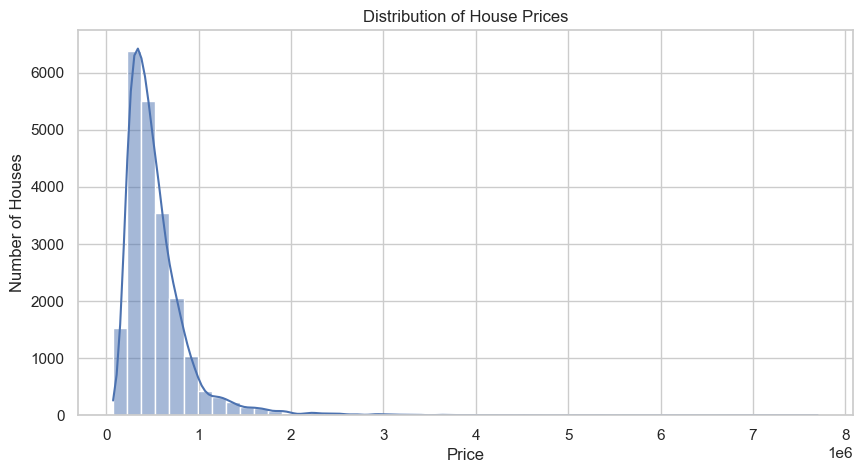

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(df["price"], bins=50, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

In [16]:
df["log_price"] = np.log1p(df["price"])

df[["price", "log_price"]].head()

,price,log_price
0,"221,900.00",12.31
1,"538,000.00",13.20
2,"180,000.00",12.10
3,"604,000.00",13.31
4,"510,000.00",13.14


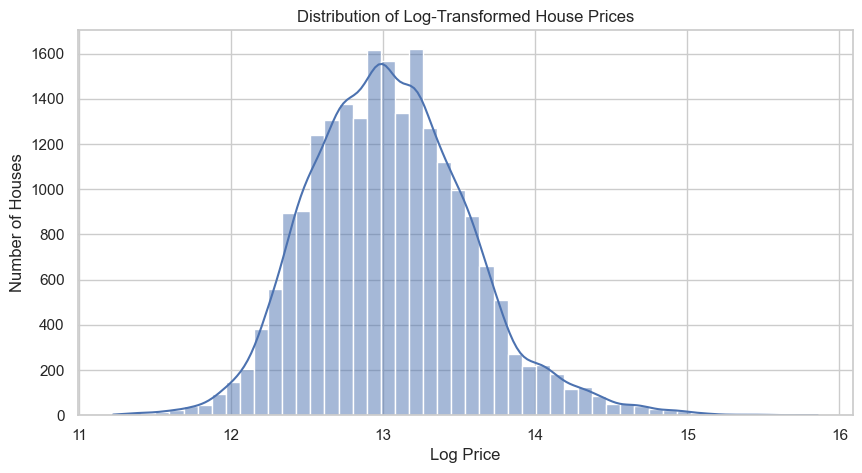

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(df["log_price"], bins=50, kde=True)

plt.title("Distribution of Log-Transformed House Prices")
plt.xlabel("Log Price")
plt.ylabel("Number of Houses")

plt.show()

## Luxury Home Definition

The project has a special focus on homes priced at $650,000 or above.

A new binary variable called `luxury_home` is created:

- `1` = house price is $650,000 or above
- `0` = house price is below $650,000

Important note: this variable is created directly from `price`, so it cannot be used as an input feature when predicting `price`. Using it in the regression model would create target leakage.

However, it will be useful later as the target variable for the classification part of the project.

In [18]:
LUXURY_THRESHOLD = 650_000

df["luxury_home"] = np.where(df["price"] >= LUXURY_THRESHOLD, 1, 0)

df["luxury_home"].value_counts()

luxury_home
0    16289
1     5324
Name: count, dtype: int64

In [20]:
luxury_distribution = df["luxury_home"].value_counts(normalize=True) * 100

luxury_distribution

luxury_home
0   75.37
1   24.63
Name: proportion, dtype: float64

In [21]:
luxury_summary = df.groupby("luxury_home")[[
    "price",
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade"
]].mean()

luxury_summary

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade
luxury_home,,,,,,,,,,
0,"392,819.76",3.22,1.93,"1,777.47","13,091.31",1.42,0.00,0.11,3.39,7.27
1,"990,661.89",3.82,2.68,"3,005.20","21,273.95",1.71,0.03,0.63,3.46,8.85


In [22]:
df["date"] = pd.to_datetime(df["date"].astype(str).str[:8], format="%Y%m%d")

df[["date"]].head()

,date
0,2014-10-13
1,2014-12-09
2,2015-02-25
3,2014-12-09
4,2015-02-18


In [23]:
df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month

df[["date", "sale_year", "sale_month"]].head()

,date,sale_year,sale_month
0,2014-10-13,2014,10
1,2014-12-09,2014,12
2,2015-02-25,2015,2
3,2014-12-09,2014,12
4,2015-02-18,2015,2


In [24]:
df["house_age"] = df["sale_year"] - df["yr_built"]

df[["sale_year", "yr_built", "house_age"]].head()

,sale_year,yr_built,house_age
0,2014,1955,59
1,2014,1951,63
2,2015,1933,82
3,2014,1965,49
4,2015,1987,28


In [25]:
df["was_renovated"] = np.where(df["yr_renovated"] > 0, 1, 0)

df["years_since_renovation"] = np.where(
    df["yr_renovated"] > 0,
    df["sale_year"] - df["yr_renovated"],
    0
)

df[["yr_renovated", "was_renovated", "years_since_renovation"]].head()

,yr_renovated,was_renovated,years_since_renovation
0,0,0,0
1,1991,1,23
2,0,0,0
3,0,0,0
4,0,0,0


In [26]:
df["has_basement"] = np.where(df["sqft_basement"] > 0, 1, 0)

df[["sqft_basement", "has_basement"]].head()

,sqft_basement,has_basement
0,0,0
1,400,1
2,0,0
3,910,1
4,0,0


In [27]:
df["price_per_sqft"] = df["price"] / df["sqft_living"]

df[["price", "sqft_living", "price_per_sqft"]].head()

,price,sqft_living,price_per_sqft
0,"221,900.00",1180,188.05
1,"538,000.00",2570,209.34
2,"180,000.00",770,233.77
3,"604,000.00",1960,308.16
4,"510,000.00",1680,303.57


In [28]:
df["zipcode"] = df["zipcode"].astype(str)

df["zipcode"].head()

0    98178
1    98125
2    98028
3    98136
4    98074
Name: zipcode, dtype: object

## Target Leakage Prevention

Some variables are useful for analysis but must not be used as predictors in the regression models.

The following variables are directly derived from `price`:

- `log_price`
- `luxury_home`
- `price_per_sqft`

These variables will be excluded from the regression feature set to avoid target leakage.

## Exploratory Data Analysis

The EDA focuses on identifying which features appear to have the strongest relationship with house prices.

This section explores:

- Correlations with price
- Relationship between price and living area
- Relationship between price and grade
- Impact of waterfront and view
- Differences between luxury and non-luxury homes
- Neighborhood patterns using zipcode

In [32]:
price_correlations = df.corr(numeric_only=True)["price"].sort_values(ascending=False)

price_correlations

price                     1.00
log_price                 0.89
sqft_living               0.70
luxury_home               0.70
grade                     0.67
sqft_above                0.61
sqft_living15             0.59
price_per_sqft            0.55
bathrooms                 0.53
view                      0.40
sqft_basement             0.32
bedrooms                  0.31
lat                       0.31
waterfront                0.27
floors                    0.26
has_basement              0.18
yr_renovated              0.13
was_renovated             0.13
sqft_lot                  0.09
sqft_lot15                0.08
years_since_renovation    0.07
yr_built                  0.05
condition                 0.04
long                      0.02
sale_year                 0.00
sale_month               -0.01
id                       -0.02
house_age                -0.05
Name: price, dtype: float64

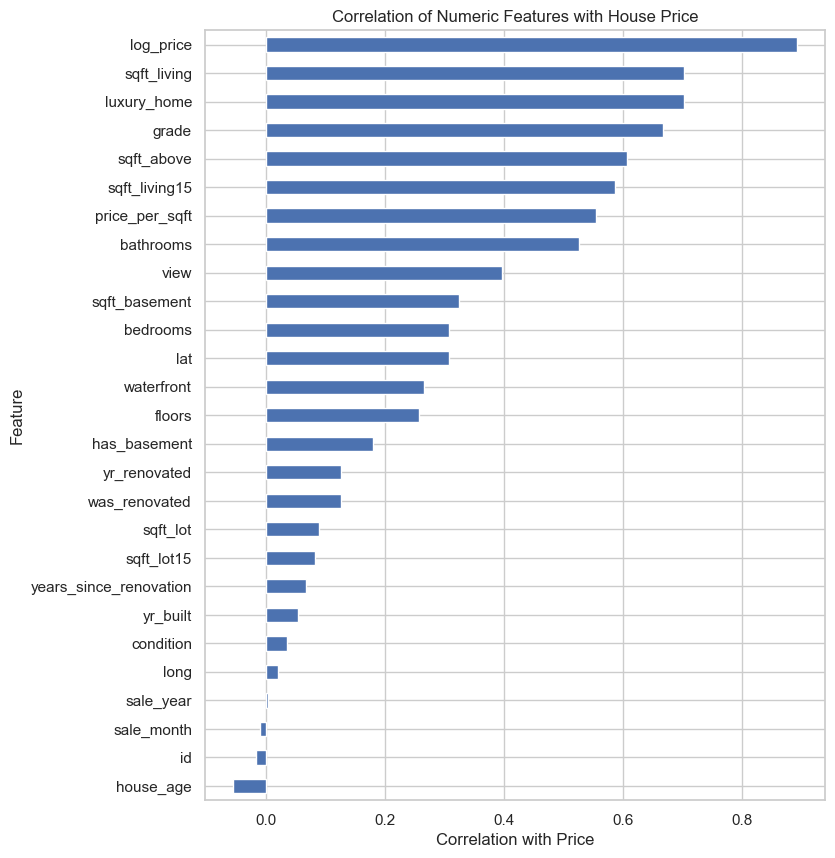

In [33]:
plt.figure(figsize=(8, 10))

price_correlations.drop("price").sort_values().plot(kind="barh")

plt.title("Correlation of Numeric Features with House Price")
plt.xlabel("Correlation with Price")
plt.ylabel("Feature")

plt.show()

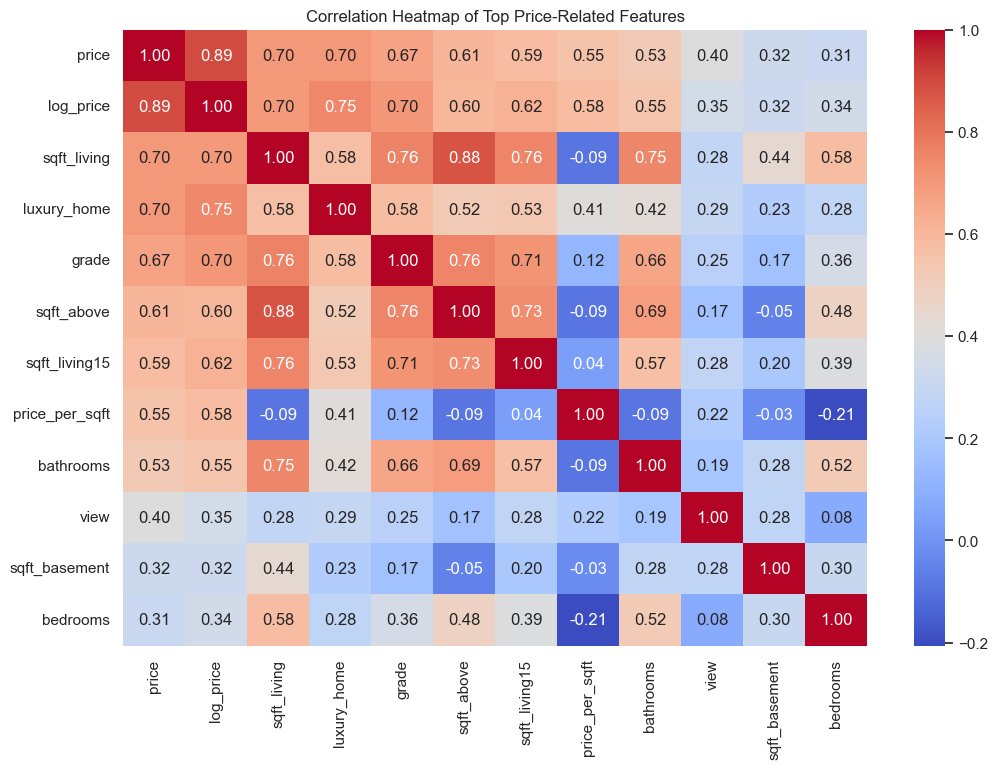

In [34]:
top_corr_features = price_correlations.abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[top_corr_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Top Price-Related Features")

plt.show()

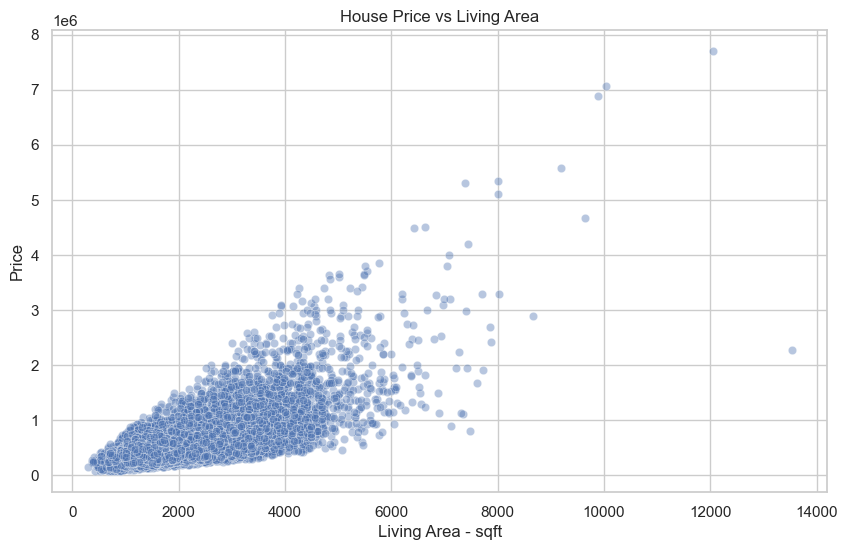

In [35]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="sqft_living",
    y="price",
    alpha=0.4
)

plt.title("House Price vs Living Area")
plt.xlabel("Living Area - sqft")
plt.ylabel("Price")

plt.show()

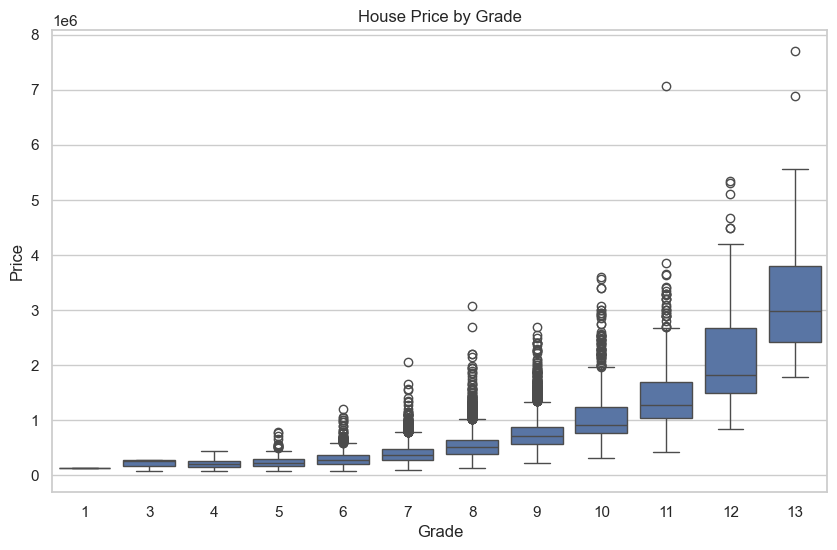

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="grade",
    y="price"
)

plt.title("House Price by Grade")
plt.xlabel("Grade")
plt.ylabel("Price")

plt.show()

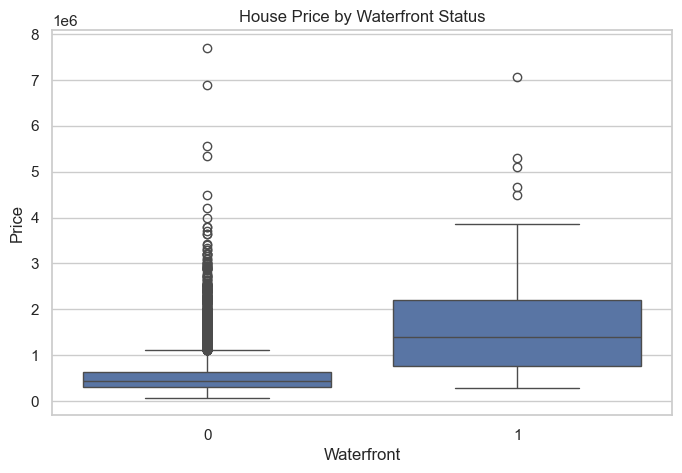

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="waterfront",
    y="price"
)

plt.title("House Price by Waterfront Status")
plt.xlabel("Waterfront")
plt.ylabel("Price")

plt.show()

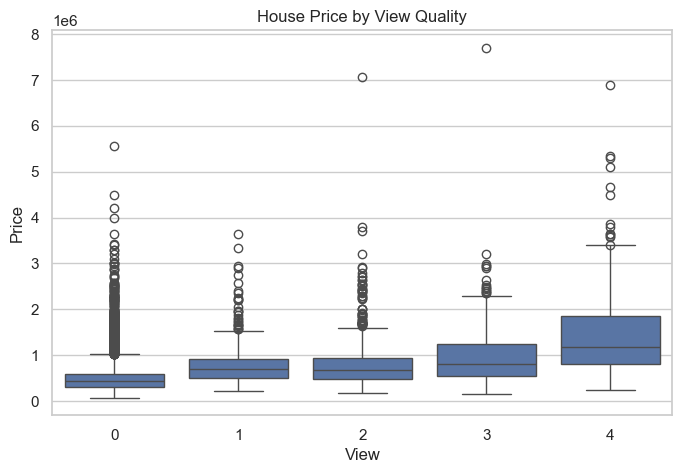

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="view",
    y="price"
)

plt.title("House Price by View Quality")
plt.xlabel("View")
plt.ylabel("Price")

plt.show()

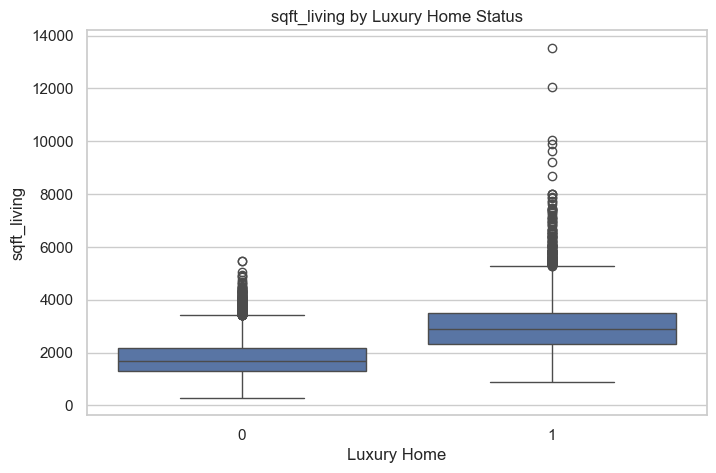

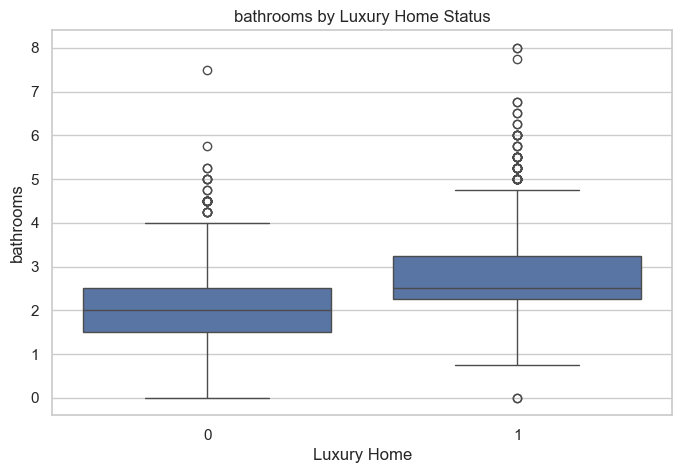

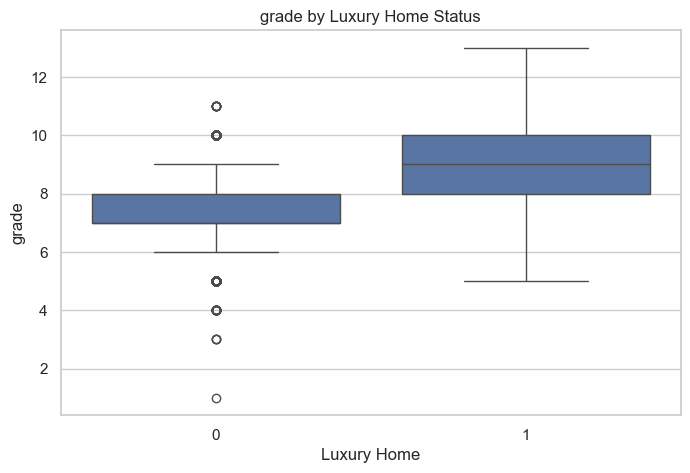

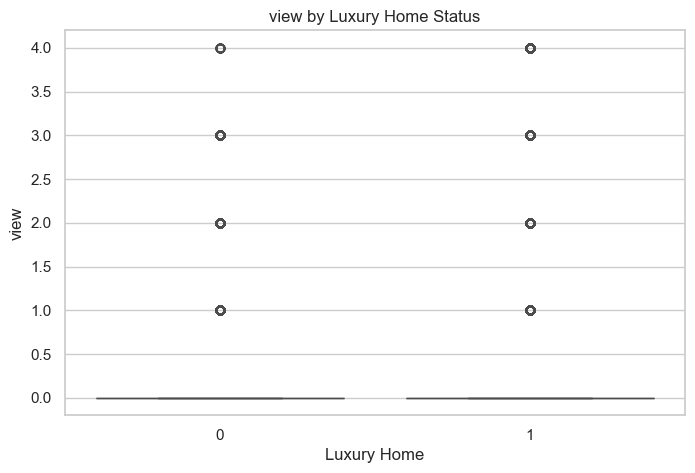

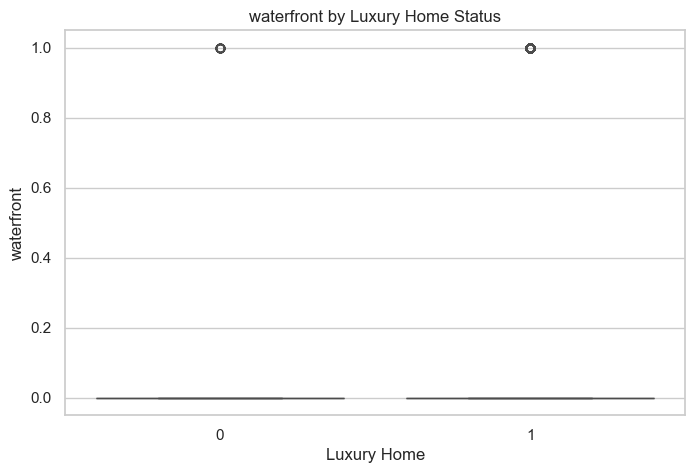

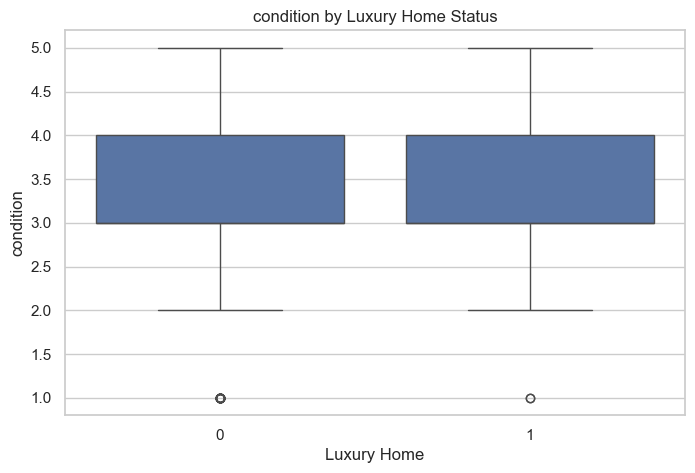

In [39]:
comparison_features = [
    "sqft_living",
    "bathrooms",
    "grade",
    "view",
    "waterfront",
    "condition"
]

for feature in comparison_features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="luxury_home",
        y=feature
    )
    
    plt.title(f"{feature} by Luxury Home Status")
    plt.xlabel("Luxury Home")
    plt.ylabel(feature)
    
    plt.show()

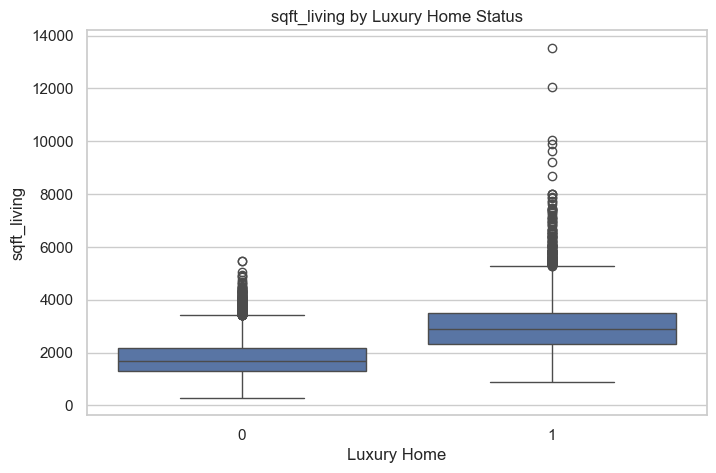

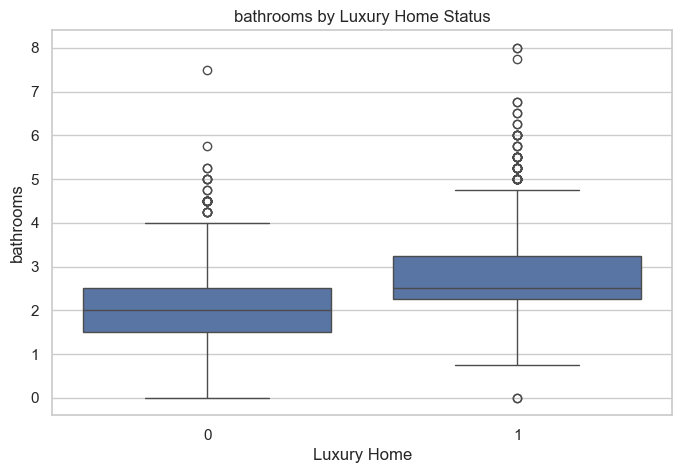

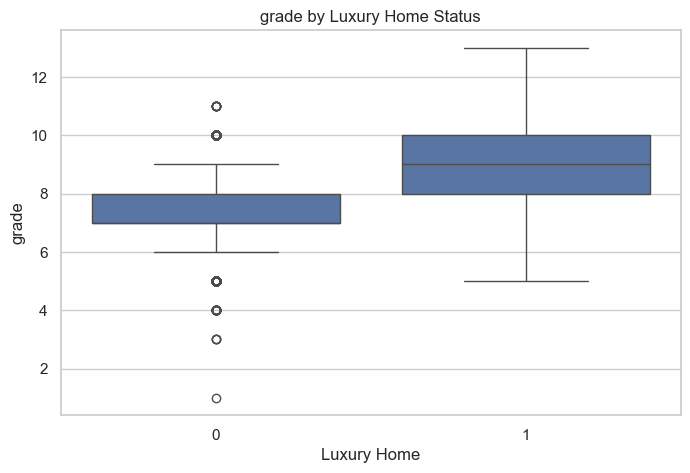

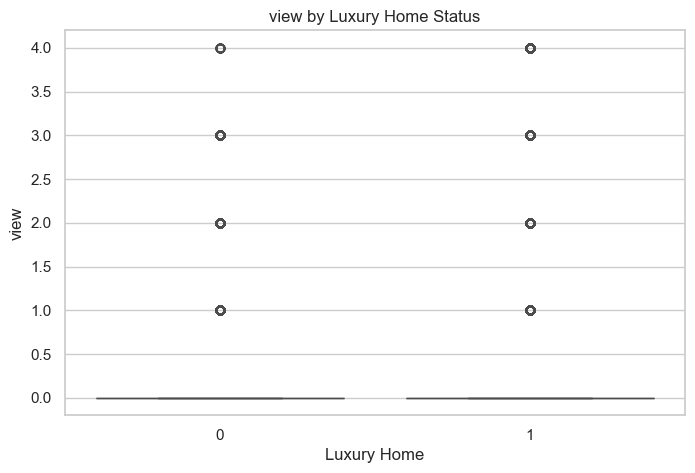

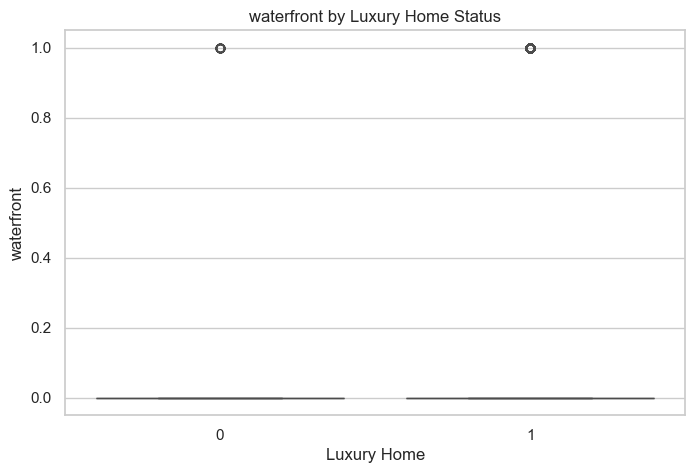

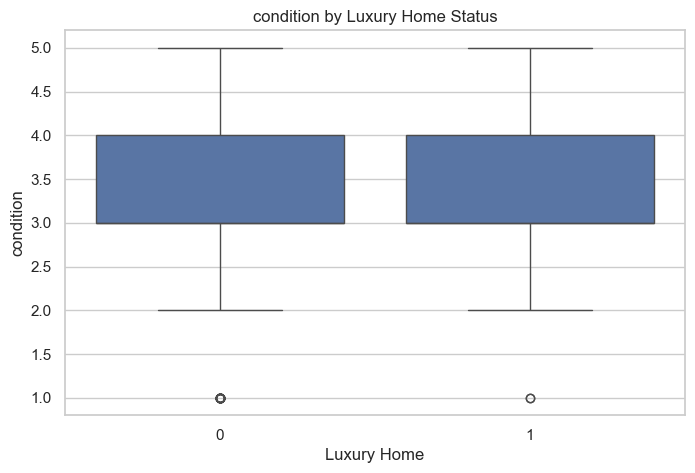

In [40]:
comparison_features = [
    "sqft_living",
    "bathrooms",
    "grade",
    "view",
    "waterfront",
    "condition"
]

for feature in comparison_features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="luxury_home",
        y=feature
    )
    
    plt.title(f"{feature} by Luxury Home Status")
    plt.xlabel("Luxury Home")
    plt.ylabel(feature)
    
    plt.show()

## Hypothesis Testing

To support the analysis statistically, a hypothesis test is performed to evaluate whether houses with higher grade have significantly different prices from houses with lower grade.

Because the original price distribution is strongly right-skewed, the test is performed using `log_price`.

In [43]:
high_grade_prices = df[df["grade"] >= 8]["log_price"]
low_grade_prices = df[df["grade"] < 8]["log_price"]

t_stat, p_value = ttest_ind(
    high_grade_prices,
    low_grade_prices,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.2e}")

print()
print(f"Average price for grade >= 8: ${df[df['grade'] >= 8]['price'].mean():,.0f}")
print(f"Average price for grade < 8: ${df[df['grade'] < 8]['price'].mean():,.0f}")

T-statistic: 96.1178
P-value: 0.00e+00

Average price for grade >= 8: $714,685
Average price for grade < 8: $380,564


In [44]:
eda_summary = df.groupby("luxury_home").agg(
    number_of_homes=("id", "count"),
    average_price=("price", "mean"),
    median_price=("price", "median"),
    average_sqft_living=("sqft_living", "mean"),
    average_bathrooms=("bathrooms", "mean"),
    average_grade=("grade", "mean"),
    average_view=("view", "mean"),
    waterfront_rate=("waterfront", "mean"),
    renovated_rate=("was_renovated", "mean"),
    average_price_per_sqft=("price_per_sqft", "mean")
)

eda_summary

,number_of_homes,average_price,median_price,average_sqft_living,average_bathrooms,average_grade,average_view,waterfront_rate,renovated_rate,average_price_per_sqft
luxury_home,,,,,,,,,,
0,16289,"392,819.76","385,000.00","1,777.47",1.93,7.27,0.11,0.00,0.03,238.65
1,5324,"990,661.89","830,000.00","3,005.20",2.68,8.85,0.63,0.03,0.08,342.19


# Price Prediction — Regression Models

The main target of this project is `price`.

In this section, several regression models are trained and compared in order to predict house prices.

The models evaluated are:

- Linear Regression
- Ridge Regression
- Lasso Regression
- KNN Regressor
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

The models will be evaluated using:

- R² Score
- MAE
- RMSE
- Train vs Test performance

In [45]:
# Model selection
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.base import clone

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Regression metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Feature Selection for Regression

To avoid target leakage, variables directly created from `price` are excluded from the regression feature set.

The following columns are not used as predictors:

- `price`: target variable
- `log_price`: transformation of the target
- `luxury_home`: created from price threshold
- `price_per_sqft`: calculated using price
- `id`: identifier, not predictive
- `date`: already transformed into year and month
- `yr_built`: replaced by `house_age`
- `yr_renovated`: replaced by renovation-related engineered features

In [46]:
target = "price"

columns_to_drop = [
    "id",
    "date",
    "price",
    "log_price",
    "luxury_home",
    "price_per_sqft",
    "yr_built",
    "yr_renovated"
]

X = df.drop(columns=columns_to_drop)
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature matrix shape: (21613, 22)
Target shape: (21613,)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age,was_renovated,years_since_renovation,has_basement
0,3,1.00,1180,5650,1.00,0,0,3,7,1180,0,98178,47.51,-122.26,1340,5650,2014,10,59,0,0,0
1,3,2.25,2570,7242,2.00,0,0,3,7,2170,400,98125,47.72,-122.32,1690,7639,2014,12,63,1,23,1
2,2,1.00,770,10000,1.00,0,0,3,6,770,0,98028,47.74,-122.23,2720,8062,2015,2,82,0,0,0
3,4,3.00,1960,5000,1.00,0,0,5,7,1050,910,98136,47.52,-122.39,1360,5000,2014,12,49,0,0,1
4,3,2.00,1680,8080,1.00,0,0,3,8,1680,0,98074,47.62,-122.05,1800,7503,2015,2,28,0,0,0


In [47]:
X.columns.tolist()

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15',
 'sale_year',
 'sale_month',
 'house_age',
 'was_renovated',
 'years_since_renovation',
 'has_basement']

In [48]:
categorical_features = ["zipcode"]

numeric_features = [col for col in X.columns if col not in categorical_features]

print("Numeric features:")
print(numeric_features)

print()
print("Categorical features:")
print(categorical_features)

Numeric features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'house_age', 'was_renovated', 'years_since_renovation', 'has_basement']

Categorical features:
['zipcode']


In [49]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", one_hot_encoder, categorical_features)
    ]
)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17290, 22)
X_test shape: (4323, 22)
y_train shape: (17290,)
y_test shape: (4323,)


## Target Transformation

House prices are strongly right-skewed. To improve model performance, the target variable is transformed using `log1p` during training.

The model learns on the log-transformed price, but predictions are automatically converted back to normal dollar prices using `expm1`.

This allows the evaluation metrics to remain interpretable in dollars.

In [51]:
regression_models = {
    "Linear Regression": LinearRegression(),
    
    "Ridge": Ridge(alpha=1.0),
    
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    
    "KNN Regressor": KNeighborsRegressor(
        n_neighbors=7
    ),
    
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [52]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", model)
    ])
    
    final_model = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    final_model.fit(X_train, y_train)
    
    train_predictions = final_model.predict(X_train)
    test_predictions = final_model.predict(X_test)
    
    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)
    
    train_mae = mean_absolute_error(y_train, train_predictions)
    test_mae = mean_absolute_error(y_test, test_predictions)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    
    results = {
        "Model": model_name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "R2 Difference": train_r2 - test_r2
    }
    
    return final_model, results

In [53]:
regression_results = []
fitted_regression_models = {}

for model_name, model in regression_models.items():
    
    fitted_model, results = evaluate_regression_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    fitted_regression_models[model_name] = fitted_model
    regression_results.append(results)

regression_results_df = pd.DataFrame(regression_results)

regression_results_df

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE,R2 Difference
0,Linear Regression,0.83,0.71,"74,142.77","80,406.33","149,957.22","208,591.72",0.12
1,Ridge,0.83,0.71,"74,192.61","80,355.97","149,430.00","208,020.27",0.12
2,Lasso,0.83,0.69,"82,701.78","89,221.89","146,892.95","217,191.65",0.15
3,KNN Regressor,0.84,0.78,"74,624.16","91,802.49","145,652.95","182,292.46",0.06
4,Decision Tree,0.91,0.82,"66,408.56","91,288.08","110,512.88","166,481.19",0.09
5,Random Forest,0.97,0.87,"37,439.19","73,142.47","64,173.63","139,056.00",0.10
6,Gradient Boosting,0.88,0.88,"70,149.22","76,566.77","123,429.86","137,271.60",0.01


In [54]:
regression_results_df = regression_results_df.sort_values(
    by="Test RMSE",
    ascending=True
).reset_index(drop=True)

regression_results_df

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE,R2 Difference
0,Gradient Boosting,0.88,0.88,"70,149.22","76,566.77","123,429.86","137,271.60",0.01
1,Random Forest,0.97,0.87,"37,439.19","73,142.47","64,173.63","139,056.00",0.10
2,Decision Tree,0.91,0.82,"66,408.56","91,288.08","110,512.88","166,481.19",0.09
3,KNN Regressor,0.84,0.78,"74,624.16","91,802.49","145,652.95","182,292.46",0.06
4,Ridge,0.83,0.71,"74,192.61","80,355.97","149,430.00","208,020.27",0.12
5,Linear Regression,0.83,0.71,"74,142.77","80,406.33","149,957.22","208,591.72",0.12
6,Lasso,0.83,0.69,"82,701.78","89,221.89","146,892.95","217,191.65",0.15


In [55]:
regression_results_formatted = regression_results_df.copy()

money_columns = ["Train MAE", "Test MAE", "Train RMSE", "Test RMSE"]

for col in money_columns:
    regression_results_formatted[col] = regression_results_formatted[col].apply(lambda x: f"${x:,.0f}")

r2_columns = ["Train R2", "Test R2", "R2 Difference"]

for col in r2_columns:
    regression_results_formatted[col] = regression_results_formatted[col].apply(lambda x: f"{x:.3f}")

regression_results_formatted

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE,R2 Difference
0,Gradient Boosting,0.883,0.875,"$70,149","$76,567","$123,430","$137,272",0.008
1,Random Forest,0.968,0.872,"$37,439","$73,142","$64,174","$139,056",0.096
2,Decision Tree,0.907,0.817,"$66,409","$91,288","$110,513","$166,481",0.090
3,KNN Regressor,0.838,0.780,"$74,624","$91,802","$145,653","$182,292",0.057
4,Ridge,0.829,0.714,"$74,193","$80,356","$149,430","$208,020",0.115
5,Linear Regression,0.828,0.712,"$74,143","$80,406","$149,957","$208,592",0.116
6,Lasso,0.835,0.688,"$82,702","$89,222","$146,893","$217,192",0.147


## Regression Metrics Interpretation

- **R² Score:** measures how much of the variance in house prices is explained by the model. Higher is better.
- **MAE:** average absolute prediction error in dollars. Lower is better.
- **RMSE:** similar to MAE, but penalizes large errors more strongly. Lower is better.
- **R2 Difference:** difference between train and test R². A large difference may indicate overfitting.

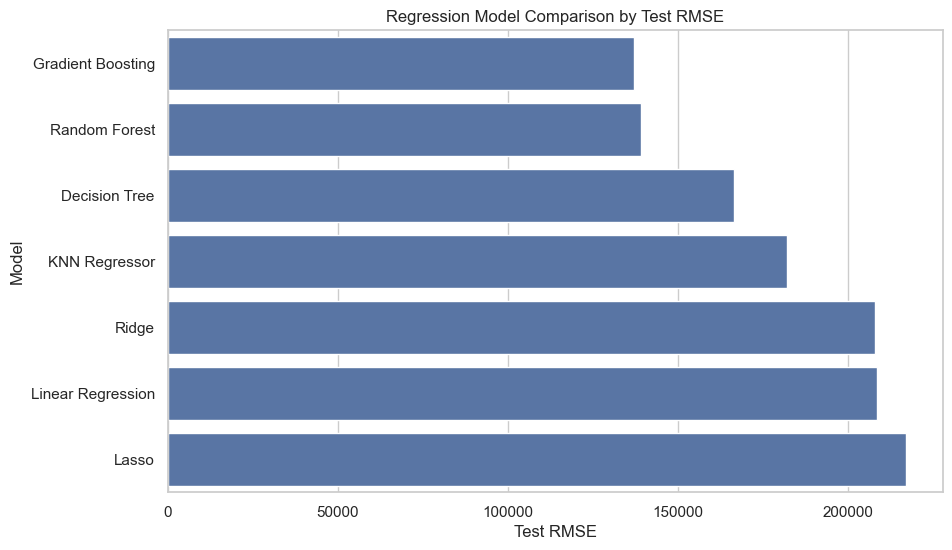

In [57]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=regression_results_df,
    x="Test RMSE",
    y="Model"
)

plt.title("Regression Model Comparison by Test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model")

plt.show()

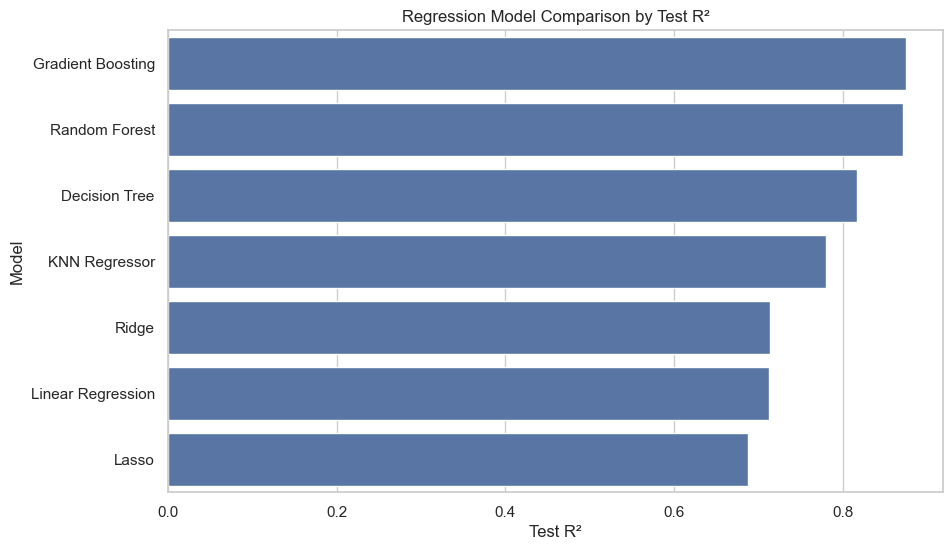

In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=regression_results_df.sort_values(by="Test R2", ascending=False),
    x="Test R2",
    y="Model"
)

plt.title("Regression Model Comparison by Test R²")
plt.xlabel("Test R²")
plt.ylabel("Model")

plt.show()

In [59]:
best_regression_model_name = regression_results_df.iloc[0]["Model"]
best_regression_model = fitted_regression_models[best_regression_model_name]

print(f"Best regression model based on Test RMSE: {best_regression_model_name}")

Best regression model based on Test RMSE: Gradient Boosting


In [60]:
best_test_predictions = best_regression_model.predict(X_test)

prediction_comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": best_test_predictions,
    "Error": y_test - best_test_predictions,
    "Absolute Error": abs(y_test - best_test_predictions)
})

prediction_comparison.head(10)

,Actual Price,Predicted Price,Error,Absolute Error
735,"365,000.00","388,127.60","-23,127.60","23,127.60"
2830,"865,000.00","766,594.52","98,405.48","98,405.48"
4106,"1,038,000.00","1,112,744.57","-74,744.57","74,744.57"
16218,"1,490,000.00","1,782,433.79","-292,433.79","292,433.79"
19964,"711,000.00","706,536.99","4,463.01","4,463.01"
1227,"211,000.00","256,743.47","-45,743.47","45,743.47"
18849,"790,000.00","745,327.08","44,672.92","44,672.92"
19369,"680,000.00","588,631.70","91,368.30","91,368.30"
20164,"384,500.00","418,233.82","-33,733.82","33,733.82"
7139,"605,000.00","528,122.14","76,877.86","76,877.86"


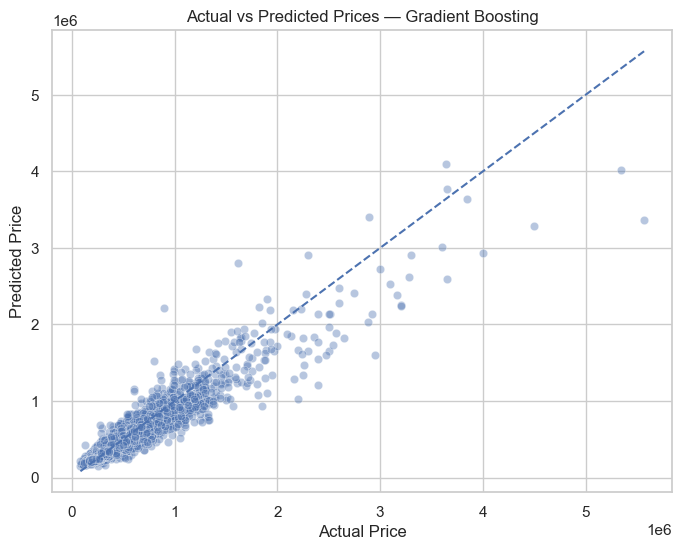

In [61]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=best_test_predictions,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(f"Actual vs Predicted Prices — {best_regression_model_name}")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

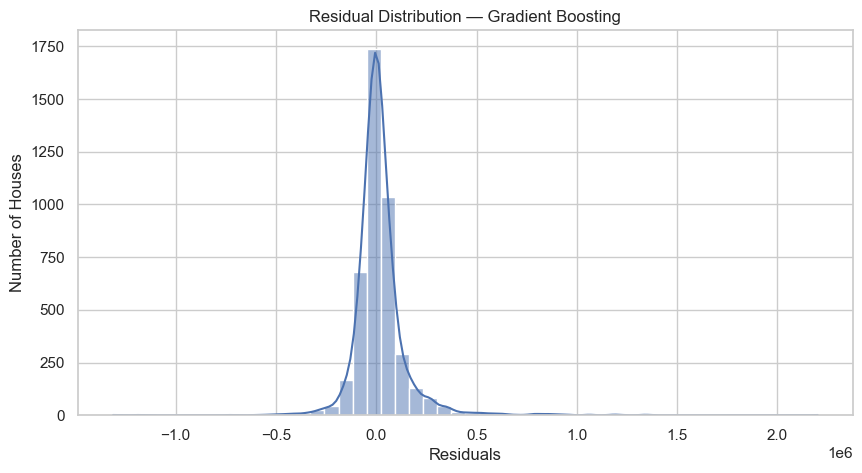

In [62]:
residuals = y_test - best_test_predictions

plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title(f"Residual Distribution — {best_regression_model_name}")
plt.xlabel("Residuals")
plt.ylabel("Number of Houses")

plt.show()

In [63]:
prediction_comparison["Price Range"] = pd.cut(
    prediction_comparison["Actual Price"],
    bins=[0, 350000, 650000, 1000000, prediction_comparison["Actual Price"].max()],
    labels=["Low", "Medium", "High", "Very High"]
)

error_by_price_range = prediction_comparison.groupby("Price Range").agg(
    number_of_homes=("Actual Price", "count"),
    average_actual_price=("Actual Price", "mean"),
    average_absolute_error=("Absolute Error", "mean")
)

error_by_price_range

C:\Users\danie\AppData\Local\Temp\ipykernel_123144\3074483730.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_price_range = prediction_comparison.groupby("Price Range").agg(


,number_of_homes,average_actual_price,average_absolute_error
Price Range,,,
Low,1375,"271,786.53","39,336.27"
Medium,1856,"484,297.84","55,135.00"
High,772,"781,176.45","100,307.46"
Very High,320,"1,560,262.38","303,571.44"


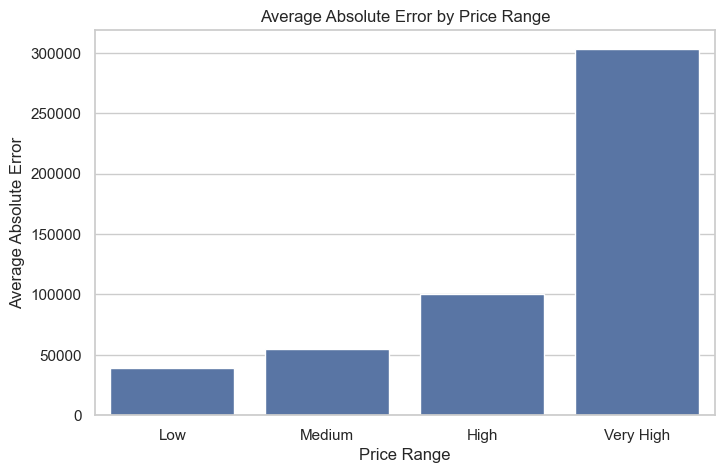

In [64]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=error_by_price_range.reset_index(),
    x="Price Range",
    y="average_absolute_error"
)

plt.title("Average Absolute Error by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Absolute Error")

plt.show()

# Feature Importance

The main objective of this project is not only to predict house prices, but also to understand which features have the strongest impact on price.

Since the best regression model is Gradient Boosting, feature importance will be extracted from this model.

This helps identify which property characteristics are most relevant when predicting house prices.

In [66]:
best_regression_model_name = regression_results_df.iloc[0]["Model"]
best_regression_model = fitted_regression_models[best_regression_model_name]

print(f"Best regression model: {best_regression_model_name}")

Best regression model: Gradient Boosting


In [67]:
best_pipeline = best_regression_model.regressor_

best_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_names[:20]

array(['numeric__bedrooms', 'numeric__bathrooms', 'numeric__sqft_living',
       'numeric__sqft_lot', 'numeric__floors', 'numeric__waterfront',
       'numeric__view', 'numeric__condition', 'numeric__grade',
       'numeric__sqft_above', 'numeric__sqft_basement', 'numeric__lat',
       'numeric__long', 'numeric__sqft_living15', 'numeric__sqft_lot15',
       'numeric__sale_year', 'numeric__sale_month', 'numeric__house_age',
       'numeric__was_renovated', 'numeric__years_since_renovation'],
      dtype=object)

In [72]:
model_importances = best_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model_importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
11,numeric__lat,0.31
8,numeric__grade,0.28
2,numeric__sqft_living,0.28
13,numeric__sqft_living15,0.02
6,numeric__view,0.02
17,numeric__house_age,0.02
12,numeric__long,0.02
24,categorical__zipcode_98004,0.01
5,numeric__waterfront,0.01
3,numeric__sqft_lot,0.01


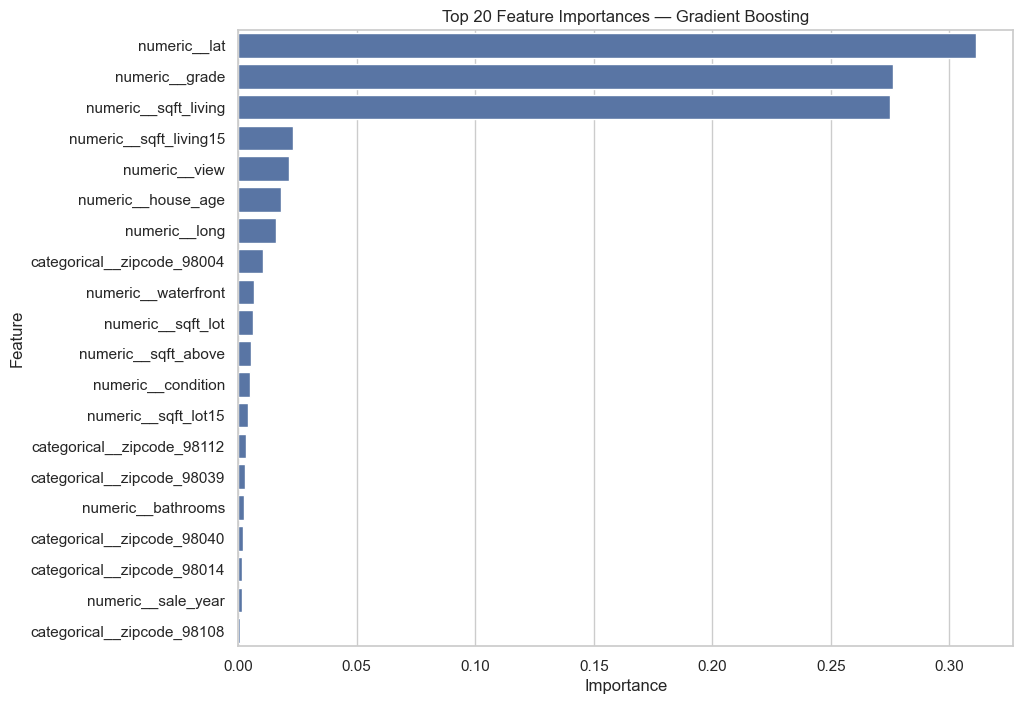

In [73]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance_df.head(20),
    x="importance",
    y="feature"
)

plt.title(f"Top 20 Feature Importances — {best_regression_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [74]:
feature_importance_clean = feature_importance_df.copy()

feature_importance_clean["feature_clean"] = (
    feature_importance_clean["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

feature_importance_clean.head(20)

,feature,importance,feature_clean
11,numeric__lat,0.31,lat
8,numeric__grade,0.28,grade
2,numeric__sqft_living,0.28,sqft_living
13,numeric__sqft_living15,0.02,sqft_living15
6,numeric__view,0.02,view
17,numeric__house_age,0.02,house_age
12,numeric__long,0.02,long
24,categorical__zipcode_98004,0.01,zipcode_98004
5,numeric__waterfront,0.01,waterfront
3,numeric__sqft_lot,0.01,sqft_lot


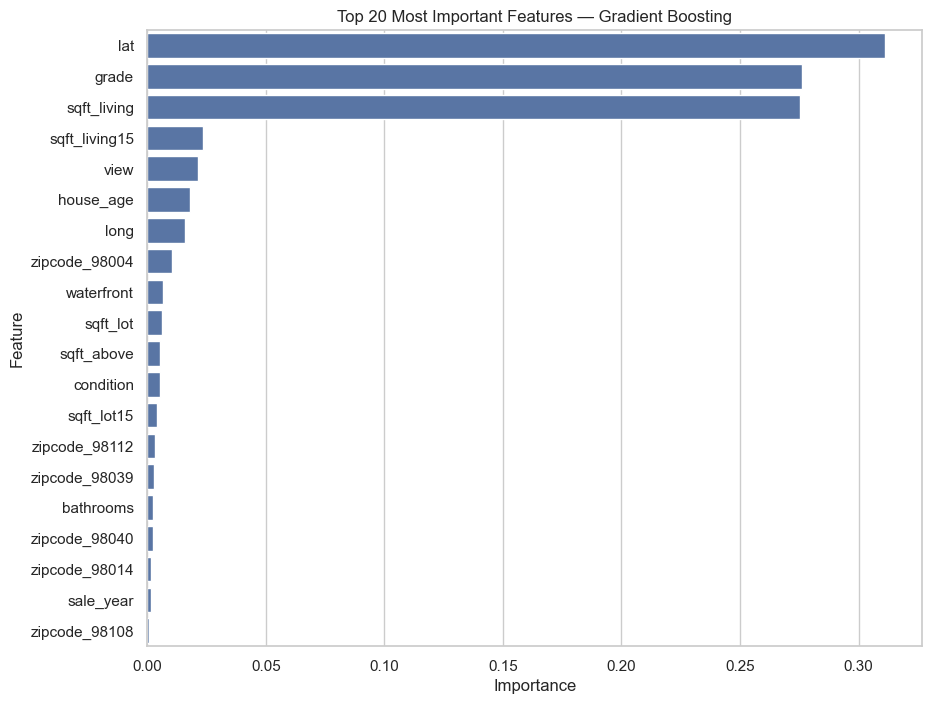

In [75]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance_clean.head(20),
    x="importance",
    y="feature_clean"
)

plt.title(f"Top 20 Most Important Features — {best_regression_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [77]:
def get_original_feature_name(feature_name):
    feature_name = feature_name.replace("numeric__", "").replace("categorical__", "")
    
    if feature_name.startswith("zipcode_"):
        return "zipcode"
    
    return feature_name


feature_importance_clean["original_feature"] = feature_importance_clean["feature"].apply(
    get_original_feature_name
)

grouped_feature_importance = (
    feature_importance_clean
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values(by="importance", ascending=False)
)

grouped_feature_importance

,original_feature,importance
7,lat,0.31
4,grade,0.28
13,sqft_living,0.28
21,zipcode,0.02
14,sqft_living15,0.02
17,view,0.02
6,house_age,0.02
8,long,0.02
19,waterfront,0.01
15,sqft_lot,0.01


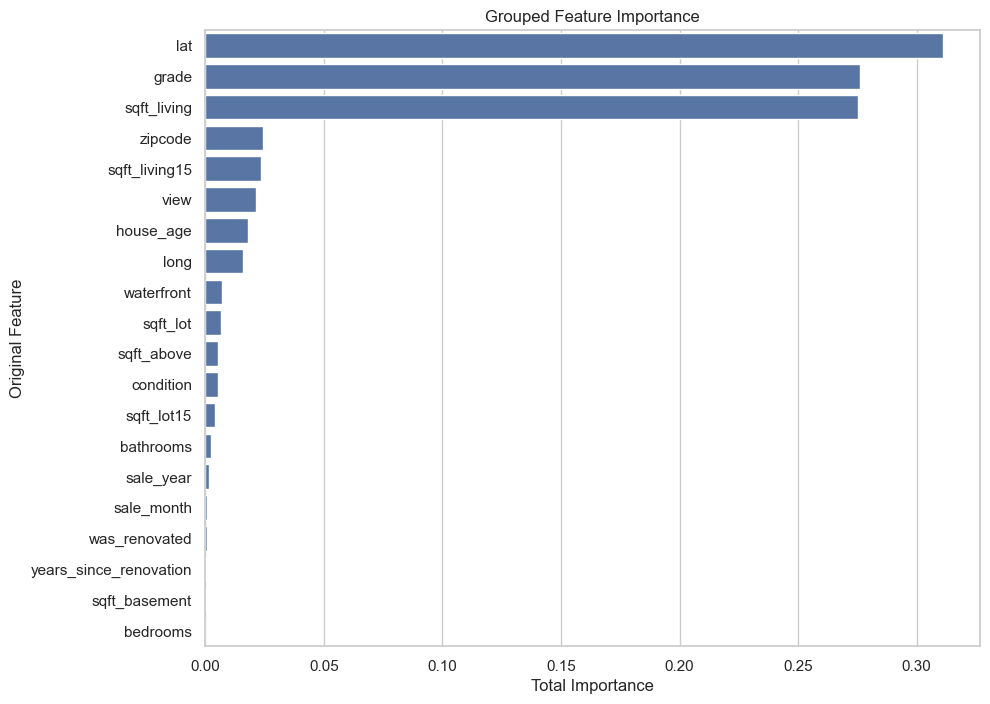

In [78]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=grouped_feature_importance.head(20),
    x="importance",
    y="original_feature"
)

plt.title("Grouped Feature Importance")
plt.xlabel("Total Importance")
plt.ylabel("Original Feature")

plt.show()

In [79]:
top_features = grouped_feature_importance.head(10).copy()

top_features["importance"] = top_features["importance"].round(4)

top_features

,original_feature,importance
7,lat,0.31
4,grade,0.28
13,sqft_living,0.28
21,zipcode,0.02
14,sqft_living15,0.02
17,view,0.02
6,house_age,0.02
8,long,0.02
19,waterfront,0.01
15,sqft_lot,0.01


# Error Analysis for Luxury Homes

The project has a special focus on houses priced at $650,000 or above.

For this reason, model errors are analyzed separately for:

- Non-luxury homes: price below $650,000
- Luxury homes: price equal to or above $650,000

This helps evaluate whether the model performs equally well across different market segments.

In [80]:
best_test_predictions = best_regression_model.predict(X_test)

prediction_analysis = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": best_test_predictions
})

prediction_analysis["error"] = prediction_analysis["actual_price"] - prediction_analysis["predicted_price"]
prediction_analysis["absolute_error"] = prediction_analysis["error"].abs()

prediction_analysis["luxury_home"] = np.where(
    prediction_analysis["actual_price"] >= LUXURY_THRESHOLD,
    1,
    0
)

prediction_analysis.head()

,actual_price,predicted_price,error,absolute_error,luxury_home
735,"365,000.00","388,127.60","-23,127.60","23,127.60",0
2830,"865,000.00","766,594.52","98,405.48","98,405.48",1
4106,"1,038,000.00","1,112,744.57","-74,744.57","74,744.57",1
16218,"1,490,000.00","1,782,433.79","-292,433.79","292,433.79",1
19964,"711,000.00","706,536.99","4,463.01","4,463.01",1


In [81]:
error_by_luxury_status = prediction_analysis.groupby("luxury_home").agg(
    number_of_homes=("actual_price", "count"),
    average_actual_price=("actual_price", "mean"),
    average_predicted_price=("predicted_price", "mean"),
    average_absolute_error=("absolute_error", "mean"),
    median_absolute_error=("absolute_error", "median")
)

error_by_luxury_status

,number_of_homes,average_actual_price,average_predicted_price,average_absolute_error,median_absolute_error
luxury_home,,,,,
0,3210,"392,184.82","400,519.97","48,309.03","35,710.53"
1,1113,"1,002,697.38","911,285.14","158,064.85","101,934.11"


In [82]:
error_by_luxury_status_formatted = error_by_luxury_status.copy()

money_columns = [
    "average_actual_price",
    "average_predicted_price",
    "average_absolute_error",
    "median_absolute_error"
]

for col in money_columns:
    error_by_luxury_status_formatted[col] = error_by_luxury_status_formatted[col].apply(
        lambda x: f"${x:,.0f}"
    )

error_by_luxury_status_formatted

,number_of_homes,average_actual_price,average_predicted_price,average_absolute_error,median_absolute_error
luxury_home,,,,,
0,3210,"$392,185","$400,520","$48,309","$35,711"
1,1113,"$1,002,697","$911,285","$158,065","$101,934"


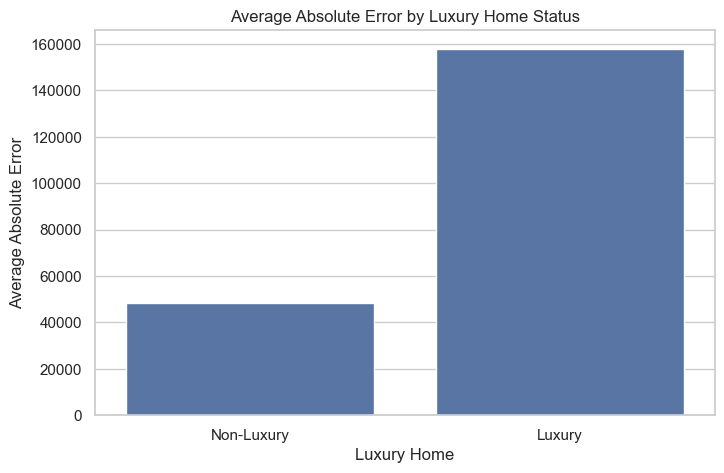

In [83]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=error_by_luxury_status.reset_index(),
    x="luxury_home",
    y="average_absolute_error"
)

plt.title("Average Absolute Error by Luxury Home Status")
plt.xlabel("Luxury Home")
plt.ylabel("Average Absolute Error")

plt.xticks(
    ticks=[0, 1],
    labels=["Non-Luxury", "Luxury"]
)

plt.show()

In [84]:
prediction_analysis["absolute_percentage_error"] = (
    prediction_analysis["absolute_error"] / prediction_analysis["actual_price"]
) * 100

percentage_error_by_luxury_status = prediction_analysis.groupby("luxury_home").agg(
    number_of_homes=("actual_price", "count"),
    average_percentage_error=("absolute_percentage_error", "mean"),
    median_percentage_error=("absolute_percentage_error", "median")
)

percentage_error_by_luxury_status

,number_of_homes,average_percentage_error,median_percentage_error
luxury_home,,,
0,3210,13.33,9.47
1,1113,14.41,11.90


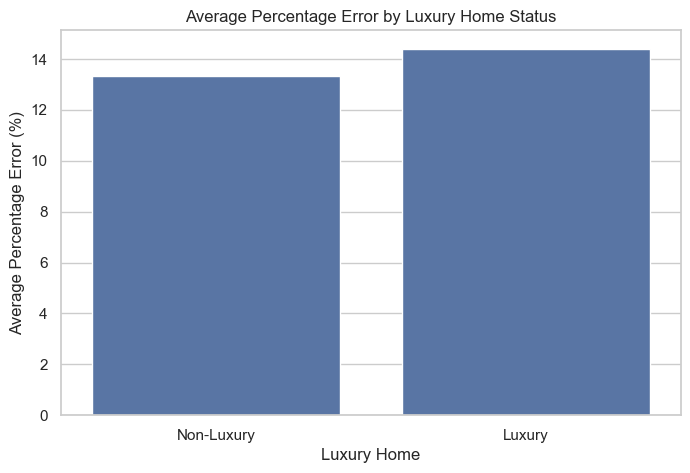

In [85]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=percentage_error_by_luxury_status.reset_index(),
    x="luxury_home",
    y="average_percentage_error"
)

plt.title("Average Percentage Error by Luxury Home Status")
plt.xlabel("Luxury Home")
plt.ylabel("Average Percentage Error (%)")

plt.xticks(
    ticks=[0, 1],
    labels=["Non-Luxury", "Luxury"]
)

plt.show()

# Luxury Home Prediction — Classification Models

The second part of the project focuses on predicting whether a house belongs to the luxury segment.

A house is classified as luxury if its sale price is equal to or above $650,000.

The target variable is:

- `luxury_home`

The models evaluated are:

- KNN Classifier
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier

The goal is to determine whether property characteristics can predict if a house belongs to the high-value segment.

In [86]:
# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Classification metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [87]:
classification_target = "luxury_home"

classification_columns_to_drop = [
    "id",
    "date",
    "price",
    "log_price",
    "luxury_home",
    "price_per_sqft",
    "yr_built",
    "yr_renovated"
]

X_class = df.drop(columns=classification_columns_to_drop)
y_class = df[classification_target]

print("Feature matrix shape:", X_class.shape)
print("Target shape:", y_class.shape)

X_class.head()

Feature matrix shape: (21613, 22)
Target shape: (21613,)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age,was_renovated,years_since_renovation,has_basement
0,3,1.00,1180,5650,1.00,0,0,3,7,1180,0,98178,47.51,-122.26,1340,5650,2014,10,59,0,0,0
1,3,2.25,2570,7242,2.00,0,0,3,7,2170,400,98125,47.72,-122.32,1690,7639,2014,12,63,1,23,1
2,2,1.00,770,10000,1.00,0,0,3,6,770,0,98028,47.74,-122.23,2720,8062,2015,2,82,0,0,0
3,4,3.00,1960,5000,1.00,0,0,5,7,1050,910,98136,47.52,-122.39,1360,5000,2014,12,49,0,0,1
4,3,2.00,1680,8080,1.00,0,0,3,8,1680,0,98074,47.62,-122.05,1800,7503,2015,2,28,0,0,0


In [88]:
class_distribution = y_class.value_counts().to_frame(name="count")
class_distribution["percentage"] = y_class.value_counts(normalize=True) * 100

class_distribution

,count,percentage
luxury_home,,
0,16289,75.37
1,5324,24.63


In [89]:
categorical_features_class = ["zipcode"]

numeric_features_class = [
    col for col in X_class.columns 
    if col not in categorical_features_class
]

print("Numeric features:")
print(numeric_features_class)

print()
print("Categorical features:")
print(categorical_features_class)

Numeric features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'house_age', 'was_renovated', 'years_since_renovation', 'has_basement']

Categorical features:
['zipcode']


In [90]:
try:
    one_hot_encoder_class = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder_class = OneHotEncoder(handle_unknown="ignore", sparse=False)

classification_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features_class),
        ("categorical", one_hot_encoder_class, categorical_features_class)
    ]
)

In [91]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("X_train_c shape:", X_train_c.shape)
print("X_test_c shape:", X_test_c.shape)
print("y_train_c distribution:")
print(y_train_c.value_counts(normalize=True))

print()
print("y_test_c distribution:")
print(y_test_c.value_counts(normalize=True))

X_train_c shape: (17290, 22)
X_test_c shape: (4323, 22)
y_train_c distribution:
luxury_home
0   0.75
1   0.25
Name: proportion, dtype: float64

y_test_c distribution:
luxury_home
0   0.75
1   0.25
Name: proportion, dtype: float64


In [92]:
classification_models = {
    "KNN Classifier": KNeighborsClassifier(
        n_neighbors=7
    ),
    
    "Decision Tree Classifier": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),
    
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting Classifier": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [93]:
def evaluate_classification_model(model_name, model, X_train, X_test, y_train, y_test):
    
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(classification_preprocessor)),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)
    
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    
    report = classification_report(
        y_test,
        test_predictions,
        output_dict=True,
        zero_division=0
    )
    
    results = {
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Precision Luxury": report["1"]["precision"],
        "Recall Luxury": report["1"]["recall"],
        "F1 Luxury": report["1"]["f1-score"],
        "Accuracy Difference": train_accuracy - test_accuracy
    }
    
    return pipeline, results

In [94]:
classification_results = []
fitted_classification_models = {}

for model_name, model in classification_models.items():
    
    fitted_model, results = evaluate_classification_model(
        model_name,
        model,
        X_train_c,
        X_test_c,
        y_train_c,
        y_test_c
    )
    
    fitted_classification_models[model_name] = fitted_model
    classification_results.append(results)

classification_results_df = pd.DataFrame(classification_results)

classification_results_df

,Model,Train Accuracy,Test Accuracy,Precision Luxury,Recall Luxury,F1 Luxury,Accuracy Difference
0,KNN Classifier,0.93,0.91,0.85,0.77,0.81,0.02
1,Decision Tree Classifier,0.95,0.92,0.84,0.82,0.83,0.04
2,Random Forest Classifier,0.97,0.92,0.90,0.78,0.84,0.05
3,Gradient Boosting Classifier,0.94,0.93,0.89,0.80,0.84,0.01


In [95]:
classification_results_df = classification_results_df.sort_values(
    by="F1 Luxury",
    ascending=False
).reset_index(drop=True)

classification_results_df

,Model,Train Accuracy,Test Accuracy,Precision Luxury,Recall Luxury,F1 Luxury,Accuracy Difference
0,Gradient Boosting Classifier,0.94,0.93,0.89,0.80,0.84,0.01
1,Random Forest Classifier,0.97,0.92,0.90,0.78,0.84,0.05
2,Decision Tree Classifier,0.95,0.92,0.84,0.82,0.83,0.04
3,KNN Classifier,0.93,0.91,0.85,0.77,0.81,0.02


In [96]:
classification_results_formatted = classification_results_df.copy()

percentage_columns = [
    "Train Accuracy",
    "Test Accuracy",
    "Precision Luxury",
    "Recall Luxury",
    "F1 Luxury",
    "Accuracy Difference"
]

for col in percentage_columns:
    classification_results_formatted[col] = classification_results_formatted[col].apply(
        lambda x: f"{x:.3f}"
    )

classification_results_formatted

,Model,Train Accuracy,Test Accuracy,Precision Luxury,Recall Luxury,F1 Luxury,Accuracy Difference
0,Gradient Boosting Classifier,0.937,0.926,0.892,0.795,0.841,0.011
1,Random Forest Classifier,0.975,0.925,0.904,0.777,0.836,0.050
2,Decision Tree Classifier,0.951,0.916,0.838,0.817,0.827,0.035
3,KNN Classifier,0.928,0.909,0.846,0.773,0.808,0.019


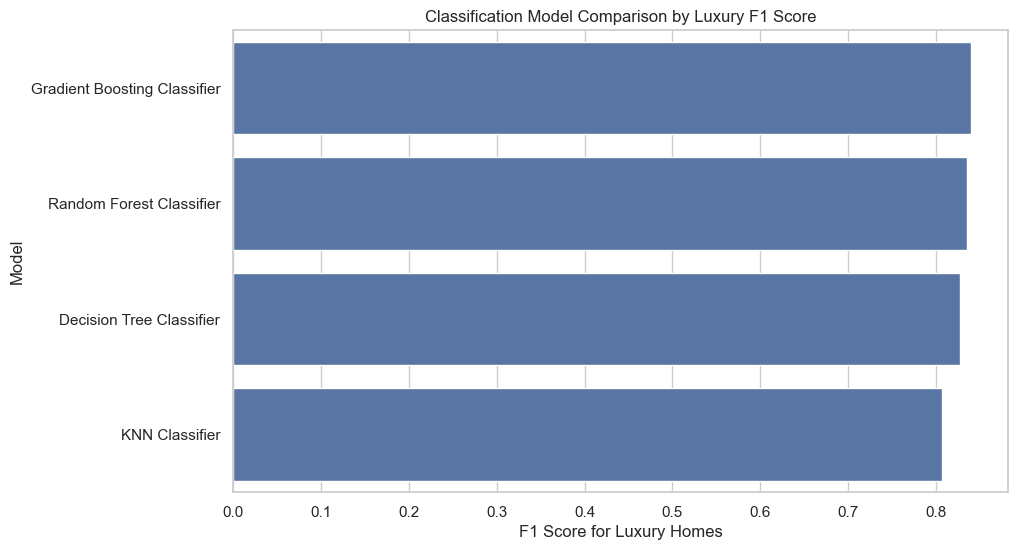

In [97]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=classification_results_df,
    x="F1 Luxury",
    y="Model"
)

plt.title("Classification Model Comparison by Luxury F1 Score")
plt.xlabel("F1 Score for Luxury Homes")
plt.ylabel("Model")

plt.show()

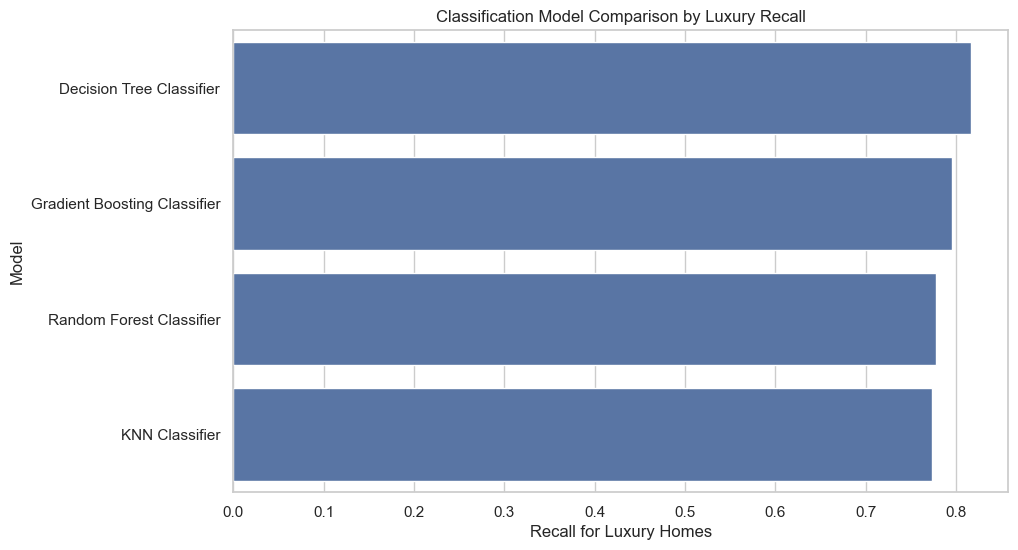

In [98]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=classification_results_df.sort_values(by="Recall Luxury", ascending=False),
    x="Recall Luxury",
    y="Model"
)

plt.title("Classification Model Comparison by Luxury Recall")
plt.xlabel("Recall for Luxury Homes")
plt.ylabel("Model")

plt.show()

In [99]:
best_classifier_name = classification_results_df.iloc[0]["Model"]
best_classifier = fitted_classification_models[best_classifier_name]

print(f"Best classification model based on Luxury F1 Score: {best_classifier_name}")

Best classification model based on Luxury F1 Score: Gradient Boosting Classifier


In [100]:
best_classifier_predictions = best_classifier.predict(X_test_c)

print(f"Classification Report — {best_classifier_name}")
print()
print(classification_report(
    y_test_c,
    best_classifier_predictions,
    target_names=["Non-Luxury", "Luxury"],
    zero_division=0
))

Classification Report — Gradient Boosting Classifier

              precision    recall  f1-score   support

  Non-Luxury       0.94      0.97      0.95      3258
      Luxury       0.89      0.80      0.84      1065

    accuracy                           0.93      4323
   macro avg       0.91      0.88      0.90      4323
weighted avg       0.92      0.93      0.92      4323



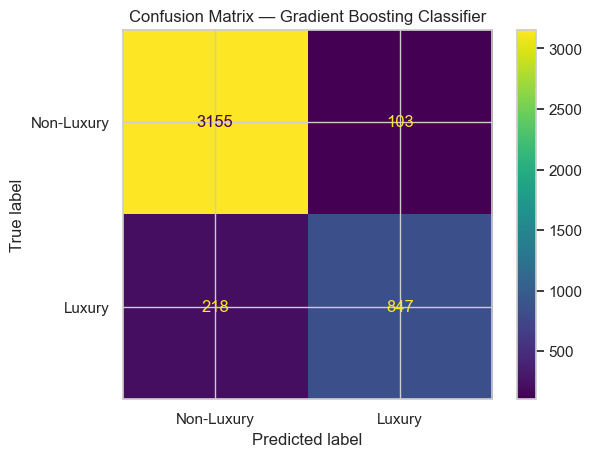

In [101]:
ConfusionMatrixDisplay.from_predictions(
    y_test_c,
    best_classifier_predictions,
    display_labels=["Non-Luxury", "Luxury"]
)

plt.title(f"Confusion Matrix — {best_classifier_name}")
plt.show()

In [103]:
classification_prediction_analysis = X_test_c.copy()

classification_prediction_analysis["actual_luxury_home"] = y_test_c
classification_prediction_analysis["predicted_luxury_home"] = best_classifier_predictions

classification_prediction_analysis["prediction_result"] = np.where(
    classification_prediction_analysis["actual_luxury_home"] == classification_prediction_analysis["predicted_luxury_home"],
    "Correct",
    "Incorrect"
)

classification_prediction_analysis.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age,was_renovated,years_since_renovation,has_basement,actual_luxury_home,predicted_luxury_home,prediction_result
1363,3,2.50,3940,10360,2.00,0,0,3,9,3110,830,98052,47.65,-122.12,2720,11941,2014,7,22,0,0,1,1,1,Correct
15268,3,3.25,1600,1289,3.00,0,0,3,8,1600,0,98117,47.70,-122.38,1600,1376,2014,8,16,0,0,0,0,0,Correct
5570,1,1.00,690,6825,1.00,0,0,4,5,690,0,98002,47.31,-122.22,1330,5381,2015,4,98,0,0,0,0,0,Correct
6398,4,2.75,3120,20031,1.00,0,2,4,9,1980,1140,98040,47.54,-122.24,3330,18777,2015,3,61,1,18,1,1,1,Correct
4340,3,1.75,1960,6380,1.00,0,0,4,7,980,980,98115,47.70,-122.32,1480,6380,2014,6,75,0,0,1,0,0,Correct


In [104]:
classification_errors = classification_prediction_analysis[
    classification_prediction_analysis["prediction_result"] == "Incorrect"
]

classification_errors.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age,was_renovated,years_since_renovation,has_basement,actual_luxury_home,predicted_luxury_home,prediction_result
883,3,1.75,2040,4000,2.00,0,0,5,7,1360,680,98105,47.67,-122.29,1610,4000,2014,9,90,0,0,1,1,0,Incorrect
10600,4,2.00,1590,5400,1.00,0,2,3,7,990,600,98119,47.64,-122.37,2190,4800,2014,9,114,0,0,1,1,0,Incorrect
16828,2,1.00,860,6510,1.00,0,0,3,7,860,0,98004,47.60,-122.20,1740,10800,2015,3,63,0,0,0,0,1,Incorrect
20693,3,3.25,1530,1565,2.00,0,0,3,8,1280,250,98122,47.62,-122.31,1530,1381,2014,6,9,0,0,1,1,0,Incorrect
13213,4,3.00,2780,5000,1.50,0,0,5,7,1710,1070,98116,47.57,-122.38,1150,5000,2014,10,95,0,0,1,1,0,Incorrect


In [105]:
classification_error_summary = classification_errors.groupby(
    ["actual_luxury_home", "predicted_luxury_home"]
).size().reset_index(name="count")

classification_error_summary

,actual_luxury_home,predicted_luxury_home,count
0,0,1,103
1,1,0,218


# House Segmentation — KMeans Clustering

The final part of the project uses KMeans clustering to segment houses into groups with similar characteristics.

Unlike regression and classification, KMeans is an unsupervised learning algorithm.  
This means that the model does not use a target variable.

The goal is to discover natural groups of houses based on:

- Size
- Quality
- Condition
- Location
- View
- Waterfront status
- Renovation status
- Basement presence

After creating the clusters, price and luxury status will be used only for interpretation.

In [106]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [107]:
cluster_features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "sqft_above",
    "sqft_basement",
    "house_age",
    "was_renovated",
    "has_basement",
    "lat",
    "long",
    "sqft_living15",
    "sqft_lot15"
]

X_cluster = df[cluster_features].copy()

X_cluster.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,house_age,was_renovated,has_basement,lat,long,sqft_living15,sqft_lot15
0,3,1.00,1180,5650,1.00,0,0,3,7,1180,0,59,0,0,47.51,-122.26,1340,5650
1,3,2.25,2570,7242,2.00,0,0,3,7,2170,400,63,1,1,47.72,-122.32,1690,7639
2,2,1.00,770,10000,1.00,0,0,3,6,770,0,82,0,0,47.74,-122.23,2720,8062
3,4,3.00,1960,5000,1.00,0,0,5,7,1050,910,49,0,1,47.52,-122.39,1360,5000
4,3,2.00,1680,8080,1.00,0,0,3,8,1680,0,28,0,0,47.62,-122.05,1800,7503


In [108]:
X_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       21613 non-null  int64  
 1   bathrooms      21613 non-null  float64
 2   sqft_living    21613 non-null  int64  
 3   sqft_lot       21613 non-null  int64  
 4   floors         21613 non-null  float64
 5   waterfront     21613 non-null  int64  
 6   view           21613 non-null  int64  
 7   condition      21613 non-null  int64  
 8   grade          21613 non-null  int64  
 9   sqft_above     21613 non-null  int64  
 10  sqft_basement  21613 non-null  int64  
 11  house_age      21613 non-null  int64  
 12  was_renovated  21613 non-null  int64  
 13  has_basement   21613 non-null  int64  
 14  lat            21613 non-null  float64
 15  long           21613 non-null  float64
 16  sqft_living15  21613 non-null  int64  
 17  sqft_lot15     21613 non-null  int64  
dtypes: flo

In [109]:
cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

X_cluster_scaled[:5]

array([[-0.39873715, -1.44746357, -0.97983502, -0.22832133, -0.915427  ,
        -0.08717263, -0.30575946, -0.62918687, -0.55883575, -0.73470764,
        -0.65868104,  0.53386491, -0.21013501, -0.80410155, -0.35257175,
        -0.30607896, -0.9433552 , -0.26071541],
       [-0.39873715,  0.1756067 ,  0.53363434, -0.18988538,  0.93650577,
        -0.08717263, -0.30575946, -0.62918687, -0.55883575,  0.46084084,
         0.2451414 ,  0.67003599,  4.75884527,  1.24362401,  1.16156823,
        -0.74634143, -0.43268619, -0.18786773],
       [-1.47395936, -1.44746357, -1.42625404, -0.12329847, -0.915427  ,
        -0.08717263, -0.30575946, -0.62918687, -1.40958711, -1.22983377,
        -0.65868104,  1.31684861, -0.21013501, -0.80410155,  1.28353661,
        -0.13565477,  1.07013975, -0.17237524],
       [ 0.67648506,  1.14944885, -0.13055006, -0.2440144 , -0.915427  ,
        -0.08717263, -0.30575946,  2.44429394, -0.55883575, -0.89169885,
         1.39751501,  0.19343721, -0.21013501,  1.243

In [110]:
k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_cluster_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster_scaled, cluster_labels)
    )

kmeans_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

kmeans_results

,k,inertia,silhouette_score
0,2,"317,194.77",0.22
1,3,"286,144.48",0.18
2,4,"262,328.03",0.19
3,5,"238,750.95",0.18
4,6,"216,362.96",0.18
5,7,"198,669.33",0.20
6,8,"187,515.17",0.19


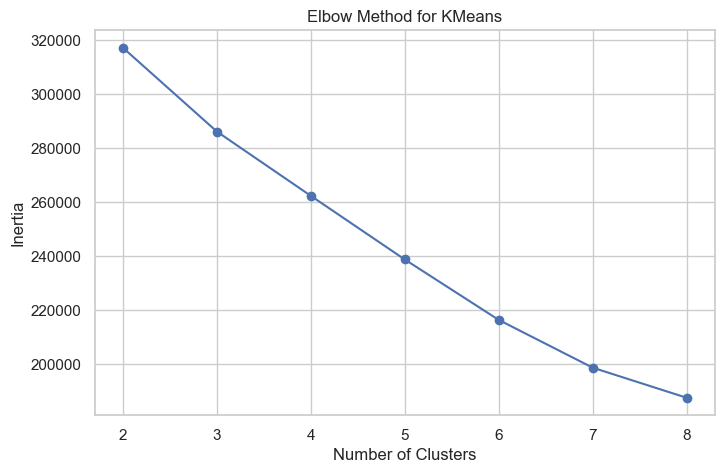

In [111]:
plt.figure(figsize=(8, 5))

plt.plot(
    kmeans_results["k"],
    kmeans_results["inertia"],
    marker="o"
)

plt.title("Elbow Method for KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

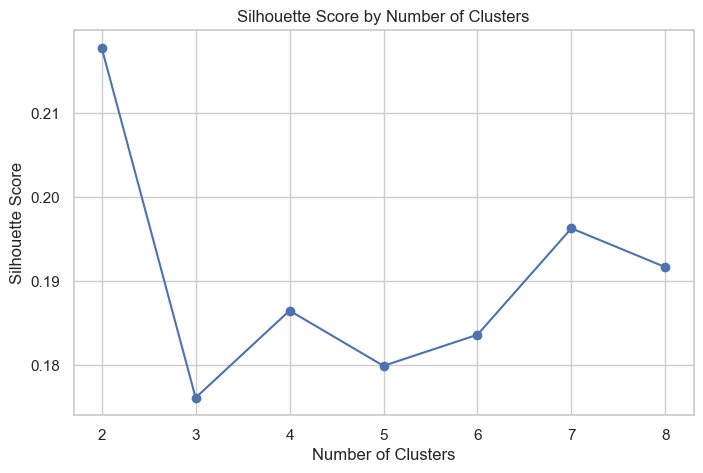

In [112]:
plt.figure(figsize=(8, 5))

plt.plot(
    kmeans_results["k"],
    kmeans_results["silhouette_score"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [113]:
best_k = kmeans_results.loc[
    kmeans_results["silhouette_score"].idxmax(),
    "k"
]

print(f"Best number of clusters based on silhouette score: {best_k}")

Best number of clusters based on silhouette score: 2


In [114]:
final_kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

df["cluster"] = final_kmeans.fit_predict(X_cluster_scaled)

df["cluster"].value_counts().sort_index()

cluster
0    13403
1     8210
Name: count, dtype: int64

In [115]:
cluster_summary = df.groupby("cluster").agg(
    number_of_homes=("id", "count"),
    average_price=("price", "mean"),
    median_price=("price", "median"),
    luxury_rate=("luxury_home", "mean"),
    average_sqft_living=("sqft_living", "mean"),
    average_sqft_lot=("sqft_lot", "mean"),
    average_bathrooms=("bathrooms", "mean"),
    average_grade=("grade", "mean"),
    average_view=("view", "mean"),
    waterfront_rate=("waterfront", "mean"),
    renovated_rate=("was_renovated", "mean"),
    average_house_age=("house_age", "mean")
).sort_values(by="average_price", ascending=False)

cluster_summary

,number_of_homes,average_price,median_price,luxury_rate,average_sqft_living,average_sqft_lot,average_bathrooms,average_grade,average_view,waterfront_rate,renovated_rate,average_house_age
cluster,,,,,,,,,,,,
1,8210,"736,090.16","612,000.00",0.46,"2,842.35","22,883.73",2.75,8.64,0.39,0.01,0.04,22.98
0,13403,"420,027.22","385,000.00",0.12,"1,612.86","10,343.32",1.73,7.06,0.14,0.00,0.04,55.78


In [116]:
cluster_summary_formatted = cluster_summary.copy()

money_columns = [
    "average_price",
    "median_price"
]

for col in money_columns:
    cluster_summary_formatted[col] = cluster_summary_formatted[col].apply(
        lambda x: f"${x:,.0f}"
    )

rate_columns = [
    "luxury_rate",
    "waterfront_rate",
    "renovated_rate"
]

for col in rate_columns:
    cluster_summary_formatted[col] = cluster_summary_formatted[col].apply(
        lambda x: f"{x:.2%}"
    )

cluster_summary_formatted

,number_of_homes,average_price,median_price,luxury_rate,average_sqft_living,average_sqft_lot,average_bathrooms,average_grade,average_view,waterfront_rate,renovated_rate,average_house_age
cluster,,,,,,,,,,,,
1,8210,"$736,090","$612,000",45.62%,"2,842.35","22,883.73",2.75,8.64,0.39,1.46%,4.09%,22.98
0,13403,"$420,027","$385,000",11.78%,"1,612.86","10,343.32",1.73,7.06,0.14,0.32%,4.31%,55.78


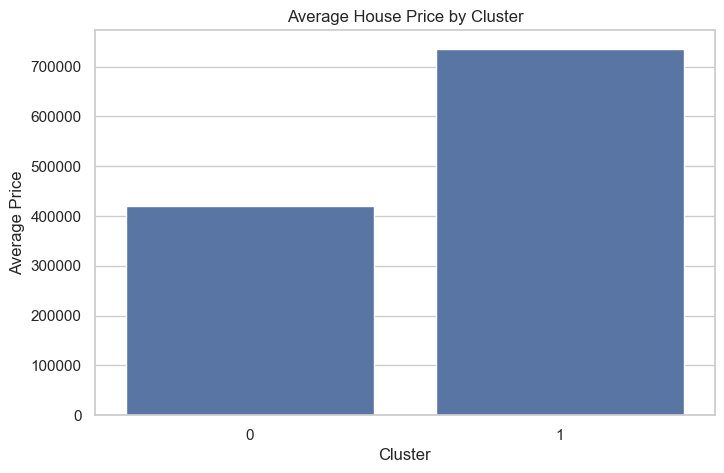

In [117]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x="cluster",
    y="average_price"
)

plt.title("Average House Price by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Price")

plt.show()

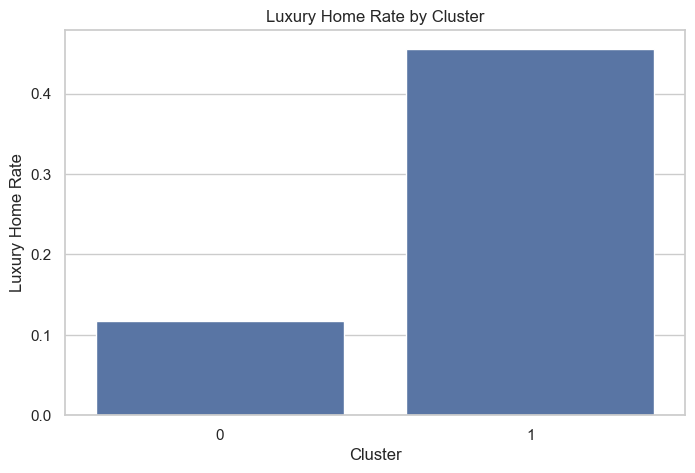

In [118]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x="cluster",
    y="luxury_rate"
)

plt.title("Luxury Home Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Luxury Home Rate")

plt.show()

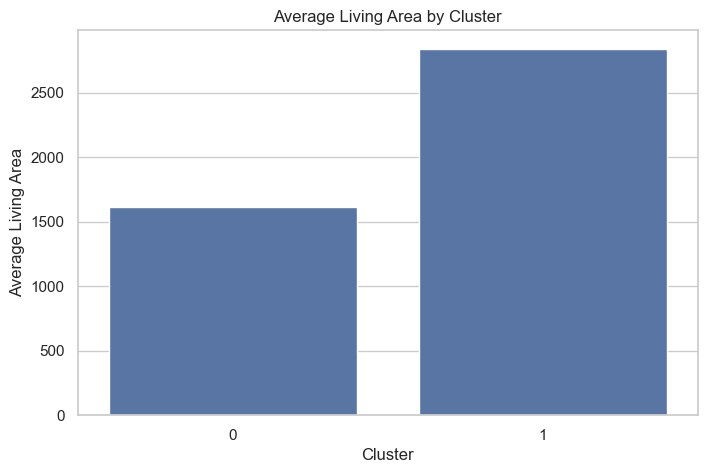

In [119]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x="cluster",
    y="average_sqft_living"
)

plt.title("Average Living Area by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Living Area")

plt.show()

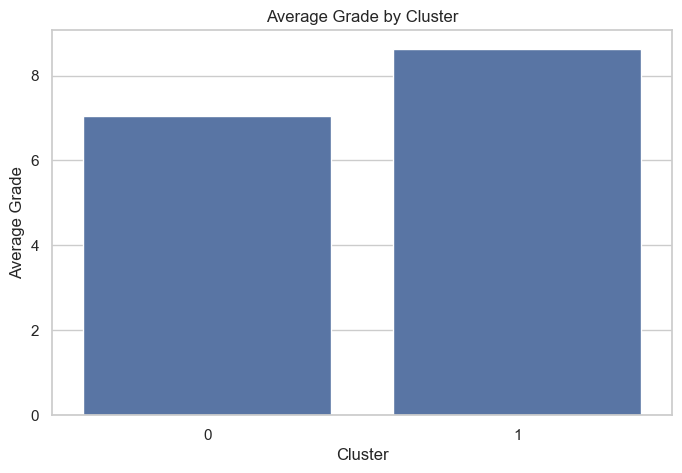

In [120]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x="cluster",
    y="average_grade"
)

plt.title("Average Grade by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Grade")

plt.show()

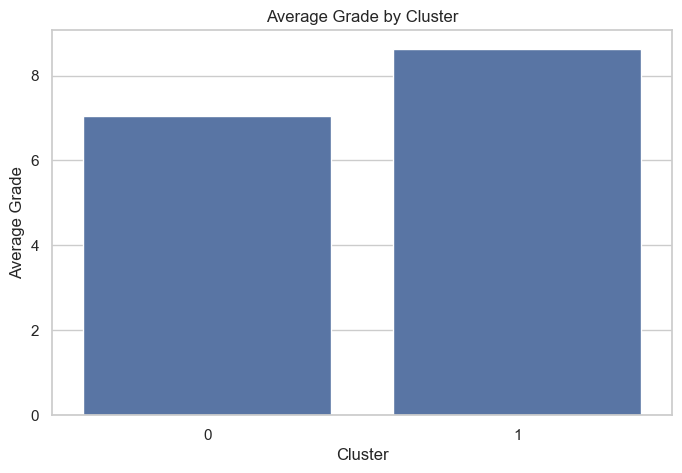

In [121]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x="cluster",
    y="average_grade"
)

plt.title("Average Grade by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Grade")

plt.show()